In [ ]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [3]:
# Import libraries
import warnings
import pandas as pd
import numpy as np
import pickle
import sys; sys.path.insert(0, '..')

from src.lgd_builder import (
    compute_actual_lgd, fit_survival_model, fit_resolution_type_model,
    fit_cf_hazard_model, fit_cf_amount_models, build_unsolved_default_fwl_data,
    compute_est_lgd
) 

pd.options.display.float_format = '{:.3f}'.format
np.set_printoptions(suppress = True)
warnings.simplefilter(action ='ignore', category = pd.errors.PerformanceWarning)
warnings.filterwarnings('ignore', category = RuntimeWarning)
warnings.filterwarnings('ignore', category = UserWarning)

In [4]:
# Import default data
df_account = pd.read_parquet(
    '../data/processed/default_account.parquet',
    engine = 'pyarrow'
)

# Import cashflow data
df_cashflow = pd.read_parquet(
    '../data/processed/default_cashflow.parquet',
    engine = 'pyarrow'
)

In [5]:
# Constant parameters
# Default information
ACC_ID_COL = "acc_id" #Primary key
RESOLUTION_COL = "resolved" #Resolution flag --> (0, 1)
EIR_COL = "eir" #EIR column for discount factor
AMOUNT_COL = "amount" #Cashflow amount column
MONTH_SINCE_DEFAULT = "month_since_default" #Month since default for discount times
EAD_COL = "ead" #Exposure at default

## Model structure
The LGD Model has built based on sample structure below:


> **Unbias LGD**
><br>
> ├── Actual LGD                        --> Resolved<br>
> ├── Estimate LGD                      --> Unsolved<br>
> ├── ├── Time to resolution model      --> Resolved + Unsolved<br>
> ├── ├── Resolution type model         --> Resolved<br>
> ├── ├── Cashflow recieve model        --> Resolved<br>
> └── └── Cashflow amount recieve model --> Resolved<br>

In [6]:
# Compute actual LGD for resolved cases
df_account = compute_actual_lgd(
    df_accounts = df_account,
    df_cashflow = df_cashflow,
    acc_id_col = ACC_ID_COL,
    resolution_col = RESOLUTION_COL,
    eir_col = EIR_COL,
    amount_col = AMOUNT_COL,
    month_s_col = MONTH_SINCE_DEFAULT,
    ead_col = EAD_COL
)

=== Processing ===
[INFO]: Actual LGD for resolved cases
=== Result ===
Resolution type   0 - LGD: 0.45%
Resolution type 202 - LGD: 55.68%
Resolution type 204 - LGD: 62.41%
Resolution type 205 - LGD: 90.48%


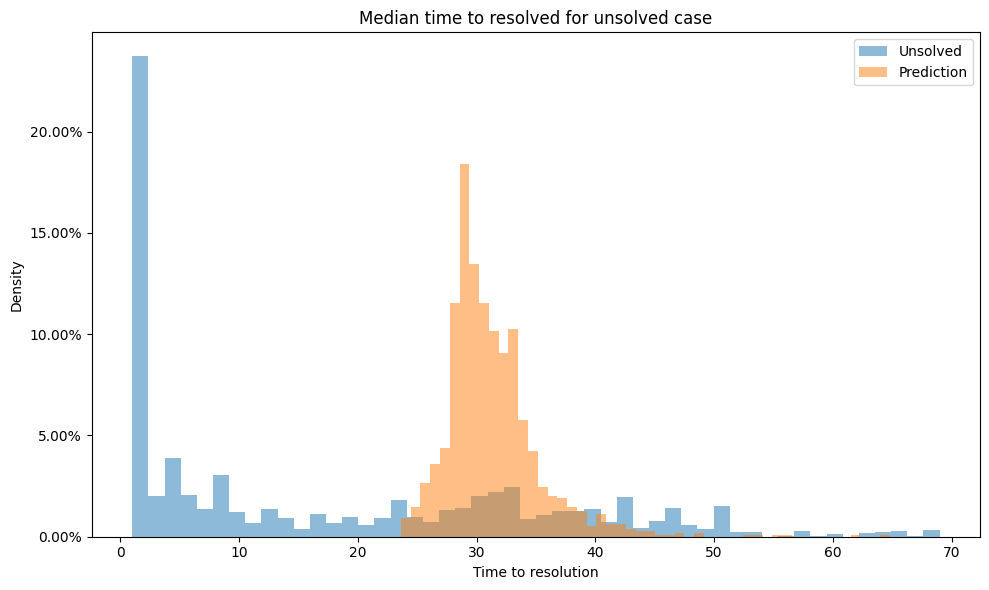

In [7]:
# Survival model for time to resolution
aft, _ = fit_survival_model(df_account)

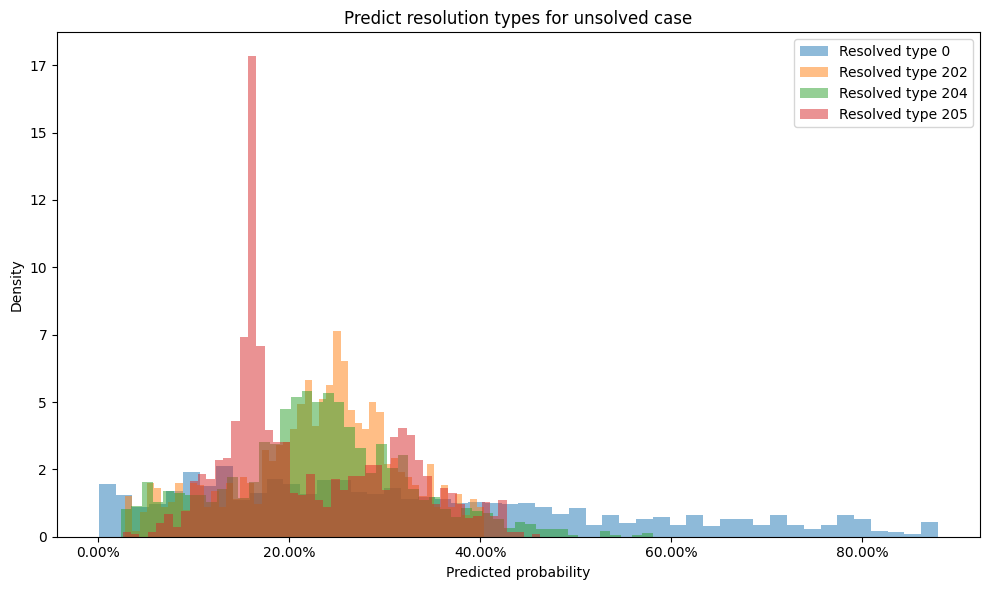

In [8]:
# Classification model for resoluation type
clf_type, le_type, _ = fit_resolution_type_model(df_account)

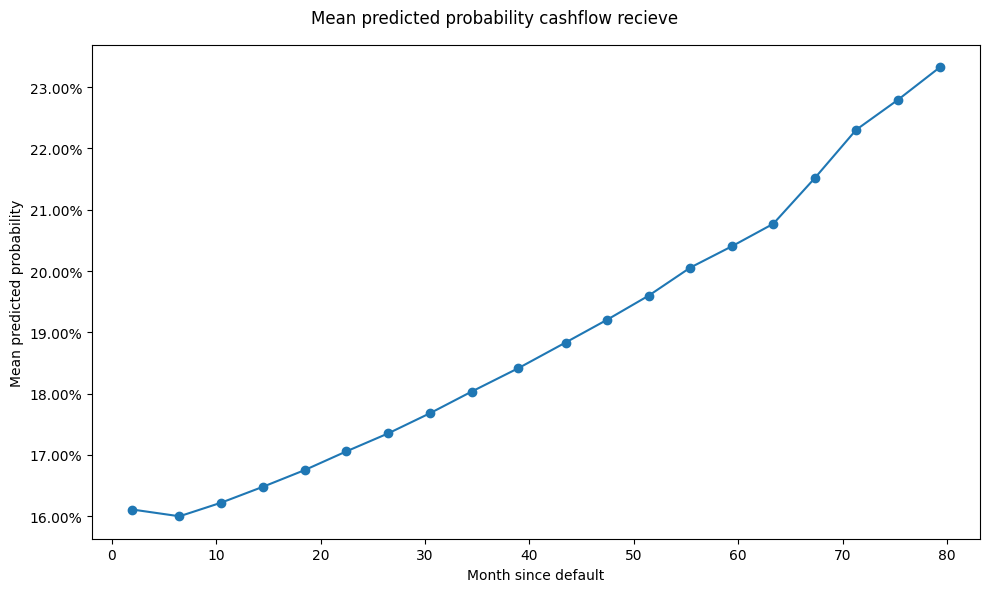

In [9]:
# Classification model for cashflow recieve
cf_hazard_model, _ = fit_cf_hazard_model(df_account, df_cashflow)

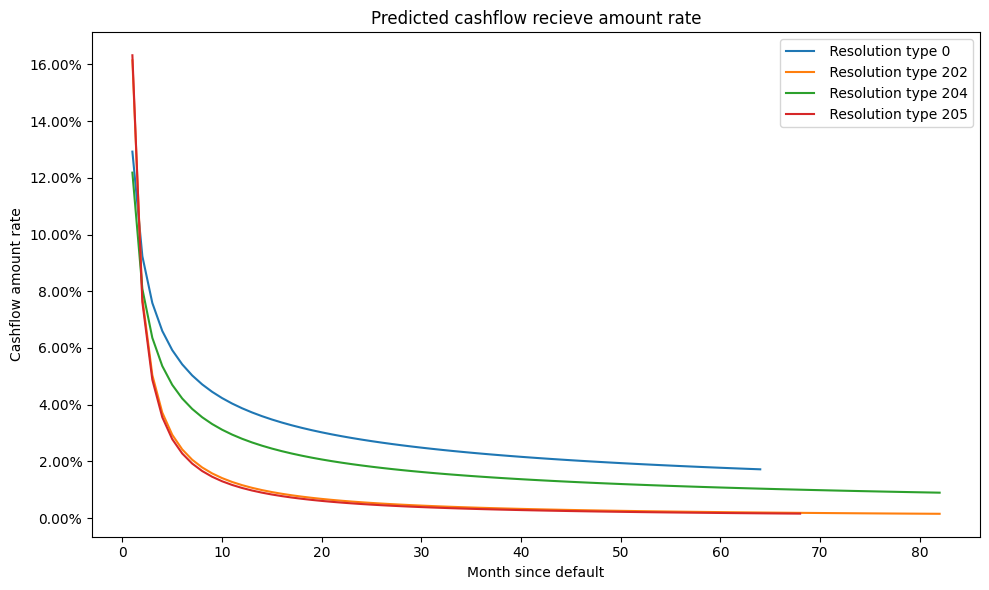

In [10]:
# Regression model for cashflow amount recieve
cf_amount_models, _ = fit_cf_amount_models(df_account, df_cashflow)

In [11]:
# Build cashflow profile for unsolved cases
df_cashflow_unsolved, prob_res_type = build_unsolved_default_fwl_data(
    df_accounts = df_account,
    aft = aft,
    clf_type = clf_type,
    le_type = le_type,
    cf_hazard_model = cf_hazard_model,
    cf_amount_models = cf_amount_models
)

In [12]:
# Unbias LGD
unbias_lgd = compute_est_lgd(
    df_account,
    df_cashflow,
    df_cashflow_unsolved,
    prob_res_type,
    outfile = True,
    file_name = "unbias_lgd"
)

[INFO]: Export - '..data/processed/unbias_lgd.parquet'

Unbias LGD Model
Total default accounts        : 24,808
    Resolved cases            : 23,481
    Unsolved cases            : 1,327
Resolved portfolio LGD        : 57.84%
    Resolution type 0         : 0.45%
    Resolution type 202       : 55.68%
    Resolution type 204       : 62.41%
    Resolution type 205       : 90.48%
Unsolved portfolio LGD        : 40.52%
    Resolution type 0         : 40.44%
    Resolution type 202       : 29.96%
    Resolution type 204       : 39.21%
    Resolution type 205       : 45.75%
Unbias portfolio LGD          : 57.03%
    Default status 100        Resolution type 0          : 18.51%
    Default status 100        Resolution type 202        : 45.57%
    Default status 100        Resolution type 204        : 61.27%
    Default status 100        Resolution type 205        : 44.29%
    Default status 202        Resolution type 202        : 57.84%
    Default status 204        Resolution type 204    

In [13]:
# Export models
all_models = [aft, clf_type, le_type, cf_hazard_model, cf_amount_models]
models_names = ["unbias_aft_model", "unbias_res_type_model", "unbias_res_type_encoder", "unbias_cf_hazard_model", "unbias_cf_amount_model"]

for name, mde in zip(models_names, all_models):
    with open(f"../model/{name}.pkl", "wb") as f:
        pickle.dump(mde, f)
    print(f"[INFO]: Export - '../model/{name}.pkl'")

[INFO]: Export - '../model/unbias_aft_model.pkl'
[INFO]: Export - '../model/unbias_res_type_model.pkl'
[INFO]: Export - '../model/unbias_res_type_encoder.pkl'
[INFO]: Export - '../model/unbias_cf_hazard_model.pkl'
[INFO]: Export - '../model/unbias_cf_amount_model.pkl'
